In [1]:
# now we would like to take an alternative approach. We will end up in a very similar position but with neural network framework.


In [10]:
import urllib.request
import torch
url = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"

urllib.request.urlretrieve(url, "names.txt")

('names.txt', <http.client.HTTPMessage at 0x1c4536a5f70>)

In [11]:
words = open('names.txt' , 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [12]:
chars = sorted(list(set(''.join(words))))      # list of all unique characters
# chars
stoi = {s:i+1 for i , s in enumerate(chars)}
# stoi
stoi['.'] = 0
stoi
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [13]:
# creating set of bigram of training model (x = input , y = target)
xs , ys = [] , []
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1 , ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        print(ch1 , ch2)
        xs.append(row)
        ys.append(col)

xs = torch.tensor(xs)
ys = torch.tensor(ys)   

. e
e m
m m
m a
a .


In [14]:
xs

tensor([ 0,  5, 13, 13,  1])

In [15]:
ys

tensor([ 5, 13, 13,  1,  0])

In [16]:
# we can not feeding this integer to the neural network so we create float vector of this integer
# for that we will use One Hot Encoding function
import torch.nn.functional as F
x_encode = F.one_hot(xs , num_classes = 27).float()
x_encode

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

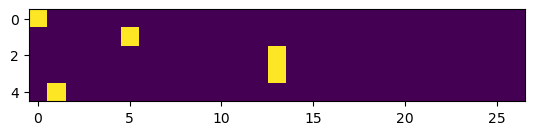

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(x_encode)

In [20]:
x_encode.dtype

torch.float32

In [21]:
# The Neural network : one linear layer of neurons implemented with matrix multiplication
W = torch.randn(27,1)
x_encode @ W     # input * weights

tensor([[ 0.1242],
        [-1.9744],
        [ 0.2657],
        [ 0.2657],
        [ 2.0122]])

In [22]:
W      # only for one neuron

tensor([[ 0.1242],
        [ 2.0122],
        [-0.9852],
        [ 0.3081],
        [-0.6761],
        [-1.9744],
        [-0.0030],
        [ 0.6592],
        [-0.3517],
        [ 0.0528],
        [-0.4857],
        [ 0.1563],
        [-0.8859],
        [ 0.2657],
        [-1.5201],
        [ 1.7686],
        [ 2.1371],
        [-1.3791],
        [ 0.6074],
        [ 0.5169],
        [-0.5592],
        [ 2.1212],
        [-1.0204],
        [ 0.8812],
        [ 0.3674],
        [-0.6726],
        [-0.2134]])

In [23]:
# for multiple neurons
W = torch.randn(27 ,27)
x_encode @ W

tensor([[ 0.0266, -0.2441, -1.4989,  2.2747,  0.6927,  1.2164,  1.0716,  0.6302,
          0.0308, -0.1628,  0.2400, -0.4060, -0.4051, -1.0893, -0.4964, -0.4942,
         -0.5828, -2.2227,  1.3971, -1.1981,  0.0263, -1.1071, -0.0418,  1.4089,
         -1.2105, -0.3892, -2.7737],
        [ 0.3114,  0.1293,  0.3157,  1.6185,  0.9963,  1.8334, -2.4348,  1.3559,
          0.5072,  0.4363, -0.9235,  0.1776,  0.0454,  0.6136,  0.0903,  0.5486,
         -1.7750,  0.8265,  0.5087, -1.1221, -0.2579,  1.5516,  0.5376, -0.7185,
         -1.1498,  0.1817,  0.1625],
        [ 0.7347, -0.5606, -1.1172, -0.2866, -0.8593,  0.4527, -0.5326,  0.4241,
         -0.3255,  0.5143,  0.2420,  1.0039,  0.7282, -0.0373, -1.3752,  0.3661,
         -1.9804,  0.3820,  0.4963, -0.9409, -0.3442,  0.4628, -2.7446, -0.9022,
         -0.1478,  0.4597,  0.0871],
        [ 0.7347, -0.5606, -1.1172, -0.2866, -0.8593,  0.4527, -0.5326,  0.4241,
         -0.3255,  0.5143,  0.2420,  1.0039,  0.7282, -0.0373, -1.3752,  0.3661

In [24]:
# (5 , 27) @ (27 , 27)  = (5 ,27) which means 5 inputs and 27 output of neuron which are input for next layer

In [26]:
# for evaluate count matrix we have to find exponent of all these (5 ,27) 
logits = x_encode @ W
counts = logits.exp()        #equivalent to N
counts

tensor([[ 1.0269,  0.7834,  0.2234,  9.7252,  1.9992,  3.3750,  2.9199,  1.8780,
          1.0313,  0.8497,  1.2712,  0.6663,  0.6669,  0.3365,  0.6087,  0.6101,
          0.5583,  0.1083,  4.0433,  0.3018,  1.0267,  0.3305,  0.9591,  4.0913,
          0.2980,  0.6776,  0.0624],
        [ 1.3654,  1.1381,  1.3712,  5.0455,  2.7082,  6.2549,  0.0876,  3.8803,
          1.6606,  1.5469,  0.3971,  1.1943,  1.0465,  1.8470,  1.0945,  1.7309,
          0.1695,  2.2853,  1.6632,  0.3256,  0.7726,  4.7190,  1.7119,  0.4875,
          0.3167,  1.1992,  1.1764],
        [ 2.0849,  0.5709,  0.3272,  0.7508,  0.4235,  1.5726,  0.5871,  1.5282,
          0.7222,  1.6725,  1.2738,  2.7290,  2.0713,  0.9634,  0.2528,  1.4421,
          0.1380,  1.4653,  1.6426,  0.3903,  0.7088,  1.5886,  0.0643,  0.4057,
          0.8626,  1.5837,  1.0910],
        [ 2.0849,  0.5709,  0.3272,  0.7508,  0.4235,  1.5726,  0.5871,  1.5282,
          0.7222,  1.6725,  1.2738,  2.7290,  2.0713,  0.9634,  0.2528,  1.4421

In [28]:
# transforming neural nets output into probabilities
probs = counts / counts.sum(1 , keepdim = True)
probs     # probabilities for the next character

tensor([[0.0254, 0.0194, 0.0055, 0.2405, 0.0494, 0.0835, 0.0722, 0.0465, 0.0255,
         0.0210, 0.0314, 0.0165, 0.0165, 0.0083, 0.0151, 0.0151, 0.0138, 0.0027,
         0.1000, 0.0075, 0.0254, 0.0082, 0.0237, 0.1012, 0.0074, 0.0168, 0.0015],
        [0.0289, 0.0241, 0.0291, 0.1069, 0.0574, 0.1325, 0.0019, 0.0822, 0.0352,
         0.0328, 0.0084, 0.0253, 0.0222, 0.0391, 0.0232, 0.0367, 0.0036, 0.0484,
         0.0352, 0.0069, 0.0164, 0.1000, 0.0363, 0.0103, 0.0067, 0.0254, 0.0249],
        [0.0721, 0.0197, 0.0113, 0.0260, 0.0146, 0.0544, 0.0203, 0.0529, 0.0250,
         0.0578, 0.0441, 0.0944, 0.0716, 0.0333, 0.0087, 0.0499, 0.0048, 0.0507,
         0.0568, 0.0135, 0.0245, 0.0549, 0.0022, 0.0140, 0.0298, 0.0548, 0.0377],
        [0.0721, 0.0197, 0.0113, 0.0260, 0.0146, 0.0544, 0.0203, 0.0529, 0.0250,
         0.0578, 0.0441, 0.0944, 0.0716, 0.0333, 0.0087, 0.0499, 0.0048, 0.0507,
         0.0568, 0.0135, 0.0245, 0.0549, 0.0022, 0.0140, 0.0298, 0.0548, 0.0377],
        [0.0209, 0.0069,